# Lab 5 - How Multilingual is mBERT?

In [1]:
!pip install -q conllu transformers datasets accelerate evaluate matplotlib seaborn pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


In [2]:
import os
import random
import urllib.request
from collections import defaultdict
from pathlib import Path
import inspect

import conllu
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)
from transformers.trainer_utils import get_last_checkpoint

os.environ["WANDB_DISABLED"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 13
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

MODEL_CHECKPOINT = "bert-base-multilingual-cased"
DATA_DIR = Path("ud_data")
DATA_DIR.mkdir(exist_ok=True)

# FINAL RUN SETTINGS
DEBUG_SMALL = False
BATCH_SIZE = 16
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

# Only used if you temporarily set DEBUG_SMALL=True.
DEBUG_TRAIN_SENTENCES = 400
DEBUG_EVAL_SENTENCES = 200

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device != "cuda":
    print("WARNING: You are not connected to a GPU. Training will be very slow.")

Device: cuda


## 1. Download Universal Dependencies Data


In [3]:
UD_REF = "master"

TREEBANKS = {
    "fr": {
        "language": "French",
        "repo": "UD_French-GSD",
        "prefix": "fr_gsd",
        "motivation": "Romance, Latin script",
    },
    "es": {
        "language": "Spanish",
        "repo": "UD_Spanish-GSD",
        "prefix": "es_gsd",
        "motivation": "Romance, Latin script",
    },
    "de": {
        "language": "German",
        "repo": "UD_German-GSD",
        "prefix": "de_gsd",
        "motivation": "Germanic, Latin script, richer case morphology",
    },
    "tr": {
        "language": "Turkish",
        "repo": "UD_Turkish-IMST",
        "prefix": "tr_imst",
        "motivation": "Turkic, Latin script, agglutinative morphology",
    },
    "ar": {
        "language": "Arabic",
        "repo": "UD_Arabic-PADT",
        "prefix": "ar_padt",
        "motivation": "Semitic, Arabic script, templatic morphology",
    },
}

WARMUP_SEQUOIA = {
    "language": "French Sequoia",
    "repo": "UD_French-Sequoia",
    "prefix": "fr_sequoia",
}

def ud_url(repo, prefix, split):
    return f"https://raw.githubusercontent.com/UniversalDependencies/{repo}/{UD_REF}/{prefix}-ud-{split}.conllu"

def download_conllu(repo, prefix, split):
    out = DATA_DIR / f"{prefix}-ud-{split}.conllu"
    if out.exists():
        return out
    url = ud_url(repo, prefix, split)
    print("Downloading", url)
    urllib.request.urlretrieve(url, out)
    return out

paths = {}
for lang, cfg in TREEBANKS.items():
    paths[lang] = {
        split: download_conllu(cfg["repo"], cfg["prefix"], split)
        for split in ["train", "dev", "test"]
    }

sequoia_test_path = download_conllu(WARMUP_SEQUOIA["repo"], WARMUP_SEQUOIA["prefix"], "test")
paths

{'fr': {'train': PosixPath('ud_data/fr_gsd-ud-train.conllu'),
  'dev': PosixPath('ud_data/fr_gsd-ud-dev.conllu'),
  'test': PosixPath('ud_data/fr_gsd-ud-test.conllu')},
 'es': {'train': PosixPath('ud_data/es_gsd-ud-train.conllu'),
  'dev': PosixPath('ud_data/es_gsd-ud-dev.conllu'),
  'test': PosixPath('ud_data/es_gsd-ud-test.conllu')},
 'de': {'train': PosixPath('ud_data/de_gsd-ud-train.conllu'),
  'dev': PosixPath('ud_data/de_gsd-ud-dev.conllu'),
  'test': PosixPath('ud_data/de_gsd-ud-test.conllu')},
 'tr': {'train': PosixPath('ud_data/tr_imst-ud-train.conllu'),
  'dev': PosixPath('ud_data/tr_imst-ud-dev.conllu'),
  'test': PosixPath('ud_data/tr_imst-ud-test.conllu')},
 'ar': {'train': PosixPath('ud_data/ar_padt-ud-train.conllu'),
  'dev': PosixPath('ud_data/ar_padt-ud-dev.conllu'),
  'test': PosixPath('ud_data/ar_padt-ud-test.conllu')}}

## 2. CoNLL-U Parsing and UD Normalization


In [4]:
def read_conllu(path):
    text = Path(path).read_text(encoding="utf-8")
    return list(conllu.parse(text))

def is_multiword_id(token_id):
    return isinstance(token_id, tuple) and len(token_id) == 3 and token_id[1] == "-"

def is_empty_node_id(token_id):
    return isinstance(token_id, tuple) and len(token_id) == 3 and token_id[1] == "."

def compact_form(form):
    # UD allows spaces inside token forms. Remove them before pre-tokenized mBERT input.
    return str(form).replace(" ", "")

def normalize_ud_sentence(sentence):
    words = []
    labels = []
    i = 0
    while i < len(sentence):
        token = sentence[i]
        token_id = token["id"]

        if is_empty_node_id(token_id):
            i += 1
            continue

        if is_multiword_id(token_id):
            start, _, end = token_id
            child_labels = []
            j = i + 1
            while j < len(sentence):
                child_id = sentence[j]["id"]
                if isinstance(child_id, int) and start <= child_id <= end:
                    child_labels.append(sentence[j]["upos"])
                if isinstance(child_id, int) and child_id >= end:
                    break
                j += 1

            words.append(compact_form(token["form"]))
            labels.append("+".join(child_labels))
            i = j + 1
            continue

        words.append(compact_form(token["form"]))
        labels.append(token["upos"])
        i += 1

    assert len(words) == len(labels)
    return words, labels

def load_normalized_corpus(path):
    return [normalize_ud_sentence(sentence) for sentence in read_conllu(path)]

def flatten(list_of_lists):
    return [item for xs in list_of_lists for item in xs]

## 3. Warm-Up on French Sequoia


,count
NOUN,2125
ADP,1320
DET,1176
PUNCT,1084
VERB,781
ADJ,636
PROPN,480
ADV,417
PRON,398
AUX,345


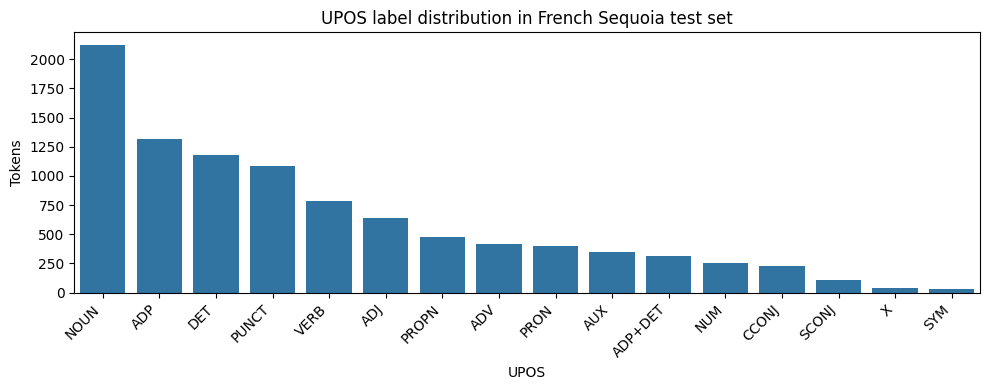

In [5]:
sequoia_sentences = read_conllu(sequoia_test_path)
sequoia_norm = [normalize_ud_sentence(s) for s in sequoia_sentences]
sequoia_words = flatten(words for words, labels in sequoia_norm)
sequoia_labels = flatten(labels for words, labels in sequoia_norm)

label_counts = pd.Series(sequoia_labels).value_counts()
display(label_counts.to_frame("count"))

plt.figure(figsize=(10, 4))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("UPOS label distribution in French Sequoia test set")
plt.ylabel("Tokens")
plt.xlabel("UPOS")
plt.tight_layout()
plt.show()

In [6]:
def collect_multiword_tokens(sentences):
    rows = []
    for sent_idx, sentence in enumerate(sentences):
        for i, token in enumerate(sentence):
            if not is_multiword_id(token["id"]):
                continue
            start, _, end = token["id"]
            children = []
            j = i + 1
            while j < len(sentence):
                child = sentence[j]
                child_id = child["id"]
                if isinstance(child_id, int) and start <= child_id <= end:
                    children.append(f"{child['form']}/{child['upos']}")
                if isinstance(child_id, int) and child_id >= end:
                    break
                j += 1
            rows.append({
                "sentence_index": sent_idx,
                "mwt_form": token["form"],
                "component_count": len(children),
                "components": " + ".join(children),
            })
    return pd.DataFrame(rows)

mwt_df = collect_multiword_tokens(sequoia_sentences)
display(mwt_df.head(20))
display(mwt_df["mwt_form"].value_counts().to_frame("count"))

tokens_with_spaces = sorted({token["form"] for sent in sequoia_sentences for token in sent if " " in str(token["form"])})
print("Number of Sequoia token types containing spaces:", len(tokens_with_spaces))
tokens_with_spaces[:50]

,sentence_index,mwt_form,component_count,components
0,1,des,2,de/ADP + les/DET
1,2,du,2,de/ADP + le/DET
2,3,Aux,2,À/ADP + les/DET
3,3,au,2,à/ADP + le/DET
4,3,du,2,de/ADP + le/DET
5,4,au,2,à/ADP + le/DET
6,5,du,2,de/ADP + le/DET
7,5,desdites,2,de/ADP + lesdites/DET
8,8,du,2,de/ADP + le/DET
9,8,des,2,de/ADP + les/DET


,count
mwt_form,
du,115
des,112
au,56
aux,21
DES,2
Au,2
Aux,1
desdites,1


Number of Sequoia token types containing spaces: 13


['100 000',
 '15 000',
 '190 500',
 '2 000',
 '3 092',
 '3 852',
 '3 862',
 '50 000',
 '500 000',
 '67 025',
 '7 736',
 '80 000',
 '800 000']

## 4. mBERT Tokenization and Label Alignment


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

example_sentence = "Pouvez-vous donner les mêmes garanties au sein de l’Union Européene"
ud_style_tokens = [
    "Pouvez", "-vous", "donner", "les", "mêmes", "garanties",
    "au", "sein", "de", "l'", "Union", "Européene",
]

print("Raw sentence:")
print(example_sentence)
print("\nUD-style tokens:")
print(ud_style_tokens)
print("\nmBERT WordPieces:")
print(tokenizer.tokenize(example_sentence))
print("\nmBERT call output keys:")
print(tokenizer(example_sentence).keys())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Raw sentence:
Pouvez-vous donner les mêmes garanties au sein de l’Union Européene

UD-style tokens:
['Pouvez', '-vous', 'donner', 'les', 'mêmes', 'garanties', 'au', 'sein', 'de', "l'", 'Union', 'Européene']

mBERT WordPieces:
['Po', '##uve', '##z', '-', 'vous', 'donner', 'les', 'mêmes', 'gara', '##nties', 'au', 'sein', 'de', 'l', '[UNK]', 'Union', 'Euro', '##pée', '##ne']

mBERT call output keys:
KeysView({'input_ids': [101, 11255, 42412, 10305, 118, 24931, 39230, 10152, 35295, 24457, 109419, 10257, 11479, 10104, 180, 100, 11457, 17526, 45249, 10238, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]})


In [8]:
def build_label_mapping(all_corpora):
    labels = sorted({label for corpus in all_corpora for words, labs in corpus for label in labs})
    label2id = {label: i for i, label in enumerate(labels)}
    id2label = {i: label for label, i in label2id.items()}
    return labels, label2id, id2label

def tokenize_and_align_labels(texts, word_labels, label2id, tokenizer):
    enc = tokenizer(
        texts,
        is_split_into_words=True,
        return_offsets_mapping=True,
        padding=True,
        truncation=True,
    )
    aligned_labels = []
    truncated_word_counts = []

    for batch_idx, labels in enumerate(word_labels):
        word_ids = enc.word_ids(batch_idx)
        offsets = enc["offset_mapping"][batch_idx]
        label_ids = []

        seen_word_ids = {wid for wid in word_ids if wid is not None}
        truncated_word_counts.append(len(labels) - len(seen_word_ids))

        for word_id, (start, end) in zip(word_ids, offsets):
            if word_id is None or (start == 0 and end == 0) or start != 0:
                label_ids.append(-100)
            else:
                label_ids.append(label2id[labels[word_id]])
        aligned_labels.append(label_ids)

    enc.pop("offset_mapping")
    enc["labels"] = aligned_labels
    return enc, truncated_word_counts

def corpus_to_dataset(corpus, label2id, tokenizer):
    texts = [words for words, labels in corpus]
    labels = [labels for words, labels in corpus]
    enc, trunc_counts = tokenize_and_align_labels(texts, labels, label2id, tokenizer)
    rows = [{key: enc[key][i] for key in enc.keys()} for i in range(len(texts))]
    return Dataset.from_list(rows), trunc_counts

## 5. Corpus Statistics, Truncation, and Dataset Objects


In [9]:
full_corpora = defaultdict(dict)
for lang, split_paths in paths.items():
    for split, path in split_paths.items():
        full_corpora[lang][split] = load_normalized_corpus(path)

def maybe_debug_sample(corpus, split):
    if not DEBUG_SMALL:
        return corpus
    n = DEBUG_TRAIN_SENTENCES if split == "train" else DEBUG_EVAL_SENTENCES
    return corpus[: min(n, len(corpus))]

all_full_corpus_lists = [full_corpora[lang][split] for lang in TREEBANKS for split in ["train", "dev", "test"]]
label_list, label2id, id2label = build_label_mapping(all_full_corpus_lists)

print("Number of non-pad labels:", len(label_list))
print(label_list)
print("Pad label id:", -100)

stats_rows = []
for lang, cfg in TREEBANKS.items():
    for split in ["train", "dev", "test"]:
        corpus = full_corpora[lang][split]
        stats_rows.append({
            "lang": lang,
            "language": cfg["language"],
            "split": split,
            "sentences": len(corpus),
            "tokens_after_mwt_normalization": sum(len(words) for words, labels in corpus),
        })

stats_df = pd.DataFrame(stats_rows)
display(stats_df)
stats_df.to_csv("corpus_stats.csv", index=False)

Number of non-pad labels: 141
['ADJ', 'ADJ+ADP', 'ADJ+ADP+ADP', 'ADJ+ADP+AUX', 'ADJ+ADP+NOUN', 'ADJ+ADP+PRON', 'ADJ+AUX', 'ADJ+PRON', 'ADP', 'ADP+ADJ', 'ADP+ADJ+PRON', 'ADP+ADP', 'ADP+AUX', 'ADP+CCONJ', 'ADP+DET', 'ADP+NOUN', 'ADP+NOUN+ADP', 'ADP+NOUN+DET', 'ADP+NOUN+PRON', 'ADP+NUM', 'ADP+PART', 'ADP+PRON', 'ADP+PROPN', 'ADP+SCONJ', 'ADP+SCONJ+PART', 'ADP+SCONJ+PRON', 'ADP+X', 'ADV', 'ADV+ADP', 'ADV+ADP+ADP', 'ADV+AUX', 'ADV+DET', 'AUX', 'AUX+AUX', 'AUX+PRON', 'AUX+VERB', 'AUX+VERB+PRON', 'CCONJ', 'CCONJ+ADJ', 'CCONJ+ADJ+PRON', 'CCONJ+ADP', 'CCONJ+ADP+ADJ', 'CCONJ+ADP+ADP', 'CCONJ+ADP+CCONJ', 'CCONJ+ADP+CCONJ+DET', 'CCONJ+ADP+DET', 'CCONJ+ADP+NOUN', 'CCONJ+ADP+NOUN+PRON', 'CCONJ+ADP+PART', 'CCONJ+ADP+PRON', 'CCONJ+ADP+SCONJ', 'CCONJ+ADP+SCONJ+PRON', 'CCONJ+ADV', 'CCONJ+AUX', 'CCONJ+AUX+AUX', 'CCONJ+AUX+VERB', 'CCONJ+AUX+VERB+PRON', 'CCONJ+CCONJ', 'CCONJ+CCONJ+DET', 'CCONJ+CCONJ+PRON', 'CCONJ+CCONJ+VERB', 'CCONJ+CCONJ+VERB+PRON', 'CCONJ+DET', 'CCONJ+DET+ADP', 'CCONJ+DET+PRON', 'CCONJ+I

,lang,language,split,sentences,tokens_after_mwt_normalization
0,fr,French,train,14450,344961
1,fr,French,dev,1476,34664
2,fr,French,test,416,9738
3,es,Spanish,train,14186,375031
4,es,Spanish,dev,1400,36461
5,es,Spanish,test,427,11733
6,de,German,train,13813,259167
7,de,German,dev,799,12316
8,de,German,test,977,16225
9,tr,Turkish,train,3435,36415


In [10]:
datasets_by_lang = defaultdict(dict)
truncation_rows = []

for lang in TREEBANKS:
    for split in ["train", "dev", "test"]:
        corpus = maybe_debug_sample(full_corpora[lang][split], split)
        ds, trunc_counts = corpus_to_dataset(corpus, label2id, tokenizer)
        datasets_by_lang[lang][split] = ds
        truncation_rows.append({
            "lang": lang,
            "split": split,
            "sentences_used": len(corpus),
            "sentences_truncated": sum(c > 0 for c in trunc_counts),
            "words_dropped_by_truncation": sum(trunc_counts),
            "pct_sentences_truncated": 100 * sum(c > 0 for c in trunc_counts) / max(1, len(corpus)),
        })

truncation_df = pd.DataFrame(truncation_rows)
display(truncation_df)
truncation_df.to_csv("truncation_stats.csv", index=False)

print("Dataset example keys:", datasets_by_lang["fr"]["train"][0].keys())
print("Input length example:", len(datasets_by_lang["fr"]["train"][0]["input_ids"]))

,lang,split,sentences_used,sentences_truncated,words_dropped_by_truncation,pct_sentences_truncated
0,fr,train,14450,1,34,0.006920
1,fr,dev,1476,0,0,0.000000
2,fr,test,416,0,0,0.000000
3,es,train,14186,0,0,0.000000
4,es,dev,1400,0,0,0.000000
5,es,test,427,0,0,0.000000
6,de,train,13813,0,0,0.000000
7,de,dev,799,0,0,0.000000
8,de,test,977,0,0,0.000000
9,tr,train,3435,0,0,0.000000


Dataset example keys: dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])
Input length example: 512


## 6. Fine-Tuning Helpers


In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    mask = labels != -100
    if mask.sum() == 0:
        return {"accuracy": 0.0}
    return {"accuracy": float((preds[mask] == labels[mask]).mean())}

def make_training_args(output_dir):
    kwargs = dict(
        output_dir=str(output_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        logging_steps=50,
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        greater_is_better=True,
    )
    try:
        return TrainingArguments(**kwargs)
    except TypeError:
        kwargs["evaluation_strategy"] = kwargs.pop("eval_strategy")
        return TrainingArguments(**kwargs)

def make_model():
    return AutoModelForTokenClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id,
    )

data_collator = DataCollatorForTokenClassification(tokenizer)

def make_trainer(model, args, train_dataset=None, eval_dataset=None):
    kwargs = dict(
        model=model,
        args=args,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    if train_dataset is not None:
        kwargs["train_dataset"] = train_dataset
    if eval_dataset is not None:
        kwargs["eval_dataset"] = eval_dataset

    params = inspect.signature(Trainer.__init__).parameters
    if "processing_class" in params:
        kwargs["processing_class"] = tokenizer
    elif "tokenizer" in params:
        kwargs["tokenizer"] = tokenizer

    return Trainer(**kwargs)

## 7. Train or Resume Full 5 x 5 Matrix


In [13]:
from google.colab import drive

drive.mount("/content/drive")

PERSIST_DIR = Path("/content/drive/MyDrive/lab5_mbert_pos")
PERSIST_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = PERSIST_DIR / "pos_transfer_matrix_partial.csv"

def train_or_load_language(train_lang):
    output_dir = PERSIST_DIR / f"checkpoints-{train_lang}"
    final_dir = PERSIST_DIR / f"final-{train_lang}"

    if (final_dir / "config.json").exists():
        print(f"Loading saved model for {train_lang}")
        model = AutoModelForTokenClassification.from_pretrained(final_dir)
        args = make_training_args(PERSIST_DIR / f"eval-{train_lang}")
        return make_trainer(model, args, eval_dataset=datasets_by_lang[train_lang]["dev"])

    print(f"\nTraining on {train_lang}: {TREEBANKS[train_lang]['language']}")
    model = make_model()
    args = make_training_args(output_dir)

    trainer = make_trainer(
        model,
        args,
        train_dataset=datasets_by_lang[train_lang]["train"],
        eval_dataset=datasets_by_lang[train_lang]["dev"],
    )

    checkpoint = get_last_checkpoint(str(output_dir)) if output_dir.exists() else None
    if checkpoint:
        print("Resuming from checkpoint:", checkpoint)
    trainer.train(resume_from_checkpoint=checkpoint)

    trainer.save_model(final_dir)
    tokenizer.save_pretrained(final_dir)
    return trainer

if RESULTS_CSV.exists():
    results_df = pd.read_csv(RESULTS_CSV, index_col=0)
else:
    results_df = pd.DataFrame(index=[], columns=list(TREEBANKS.keys()), dtype=float)

for train_lang in TREEBANKS:
    if train_lang in results_df.index and results_df.loc[train_lang].notna().all():
        print(f"Skipping {train_lang}; row already complete.")
        continue

    trainer = train_or_load_language(train_lang)

    for test_lang in TREEBANKS:
        if train_lang in results_df.index and pd.notna(results_df.loc[train_lang, test_lang]):
            print(f"Skipping existing cell {train_lang}->{test_lang}: {results_df.loc[train_lang, test_lang]:.4f}")
            continue
        metrics = trainer.evaluate(eval_dataset=datasets_by_lang[test_lang]["test"])
        results_df.loc[train_lang, test_lang] = metrics["eval_accuracy"]
        results_df = results_df.loc[sorted(results_df.index), list(TREEBANKS.keys())]
        results_df.to_csv(RESULTS_CSV)
        display(results_df)

    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

results_df = results_df.loc[list(TREEBANKS.keys()), list(TREEBANKS.keys())]
display(results_df)
results_df.to_csv(PERSIST_DIR / "pos_transfer_matrix.csv")

Mounted at /content/drive

Training on fr: French


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly ini

Epoch,Training Loss,Validation Loss,Accuracy
1,0.068079,0.057084,0.983556
2,0.041792,0.050529,0.986009
3,0.028384,0.052212,0.986528


...

,fr,es,de,tr,ar
ar,0.608441,0.619535,NaN,NaN,NaN
de,0.860546,0.864485,0.968197,0.738872,0.516136
es,0.934381,0.968721,0.875624,0.747179,0.542911
fr,0.982235,0.927299,0.876055,0.760615,0.561010
tr,0.659376,0.654479,0.713529,0.900205,0.460807


,fr,es,de,tr,ar
ar,0.608441,0.619535,0.626995,NaN,NaN
de,0.860546,0.864485,0.968197,0.738872,0.516136
es,0.934381,0.968721,0.875624,0.747179,0.542911
fr,0.982235,0.927299,0.876055,0.760615,0.561010
tr,0.659376,0.654479,0.713529,0.900205,0.460807


,fr,es,de,tr,ar
ar,0.608441,0.619535,0.626995,0.556718,NaN
de,0.860546,0.864485,0.968197,0.738872,0.516136
es,0.934381,0.968721,0.875624,0.747179,0.542911
fr,0.982235,0.927299,0.876055,0.760615,0.561010
tr,0.659376,0.654479,0.713529,0.900205,0.460807


,fr,es,de,tr,ar
ar,0.608441,0.619535,0.626995,0.556718,0.951820
de,0.860546,0.864485,0.968197,0.738872,0.516136
es,0.934381,0.968721,0.875624,0.747179,0.542911
fr,0.982235,0.927299,0.876055,0.760615,0.561010
tr,0.659376,0.654479,0.713529,0.900205,0.460807


,fr,es,de,tr,ar
fr,0.982235,0.927299,0.876055,0.760615,0.561010
es,0.934381,0.968721,0.875624,0.747179,0.542911
de,0.860546,0.864485,0.968197,0.738872,0.516136
tr,0.659376,0.654479,0.713529,0.900205,0.460807
ar,0.608441,0.619535,0.626995,0.556718,0.951820


## 8. Heatmap and Saved Artifacts



,fr,es,de,tr,ar
fr,0.982235,0.927299,0.876055,0.760615,0.561010
es,0.934381,0.968721,0.875624,0.747179,0.542911
de,0.860546,0.864485,0.968197,0.738872,0.516136
tr,0.659376,0.654479,0.713529,0.900205,0.460807
ar,0.608441,0.619535,0.626995,0.556718,0.951820


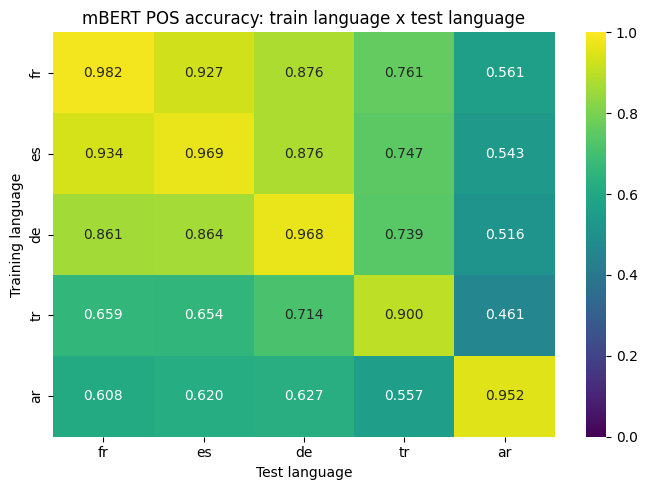

Saved artifacts in: /content/drive/MyDrive/lab5_mbert_pos
- corpus_stats.csv
- truncation_stats.csv
- pos_transfer_matrix.csv / pos_transfer_matrix_partial.csv
- pos_transfer_matrix.png


In [14]:
PERSIST_DIR = Path("/content/drive/MyDrive/lab5_mbert_pos")
RESULTS_CSV = PERSIST_DIR / "pos_transfer_matrix.csv"
if not RESULTS_CSV.exists():
    RESULTS_CSV = PERSIST_DIR / "pos_transfer_matrix_partial.csv"

results_df = pd.read_csv(RESULTS_CSV, index_col=0)
results_df = results_df.reindex(index=list(TREEBANKS.keys()), columns=list(TREEBANKS.keys()))
display(results_df)

plt.figure(figsize=(7, 5))
sns.heatmap(results_df.astype(float), annot=True, fmt=".3f", cmap="viridis", vmin=0, vmax=1)
plt.title("mBERT POS accuracy: train language x test language")
plt.xlabel("Test language")
plt.ylabel("Training language")
plt.tight_layout()
plt.savefig(PERSIST_DIR / "pos_transfer_matrix.png", dpi=200)
plt.show()

print("Saved artifacts in:", PERSIST_DIR)
print("- corpus_stats.csv")
print("- truncation_stats.csv")
print("- pos_transfer_matrix.csv / pos_transfer_matrix_partial.csv")
print("- pos_transfer_matrix.png")